# Quasi-regular grids construction for quantum dynamics calculations

In this simple tutorial, we demonstrate how to construct quasi-regular grids that could be used in quantum dynamics calculations.

## Table of contents
<a name="toc"></a>
   

### A. Learning objectives

* To construct quasi-regular grids


### B. Use cases

* construct non-uniform grids


### C. Functions

- `libra_py`
  - `grids`
    - [`construct_grid_qrg_fast`](#construct_grid_qrg_fast-1)


In [11]:
import torch
from libra_py import grids

<a name="construct_grid_qrg_fast-1"></a>

In [12]:
help(grids.construct_grid_qrg_fast)

Help on function construct_grid_qrg_fast in module libra_py.grids:

construct_grid_qrg_fast(N_MC, rg, V_, P, rrange1, device='cpu', step=0.01)
    Optimize a quantum reference grid (QRG) using Monte Carlo sampling.
    
    This routine performs a stochastic optimization of grid points by
    minimizing the total pairwise repulsive energy between them.
    The algorithm is equivalent to the Fortran routine `Construct_grid_QRG`.
    
    The optimization proceeds by repeatedly proposing random displacements
    of individual grid points and accepting only energy-lowering moves
    (zero-temperature Monte Carlo).
    
    Parameters
    ----------
    N_MC : int
        Number of Monte Carlo sweeps per grid point.
        Total number of trial moves = NG * N_MC.
    
    rg : torch.Tensor, shape (d1, NG)
        Coordinates of grid points.
    
    V_ : torch.Tensor, shape (NG,)
        Potential energy at each grid point.
    
    P : callable
        Function evaluating the probability

## 1. 2D case

In [13]:
d1 = 2
NG = 25

rg = torch.randn(d1, NG)
V_ = torch.zeros(NG)
rrange1 = torch.ones(d1)

def P(r):
    V = 0.025*torch.sum(r**2)
    Pval = torch.exp(-V)
    return Pval, V

rg_opt, sigma, V = grids.construct_grid_qrg_fast(
    N_MC=500,
    rg=rg,
    V_=V_,
    P=P,
    rrange1=rrange1,
    device="cpu",
    step=0.1
)

Start optimizing QRG
Step 250 | step_size = 0.0900 | energy = 4345.2212
Step 500 | step_size = 0.0810 | energy = 556.3174
Step 750 | step_size = 0.0810 | energy = 66.3827
Step 1000 | step_size = 0.0729 | energy = 58.3099
Step 1250 | step_size = 0.0729 | energy = 1.5833
Step 1500 | step_size = 0.0656 | energy = 6.5820
Step 1750 | step_size = 0.0656 | energy = 8.9900
Step 2000 | step_size = 0.0656 | energy = 4.3609
Step 2250 | step_size = 0.0590 | energy = 0.1049
Step 2500 | step_size = 0.0531 | energy = 0.0835
Step 2750 | step_size = 0.0478 | energy = 0.5804
Step 3000 | step_size = 0.0430 | energy = 0.8902
Step 3250 | step_size = 0.0430 | energy = 0.2147
Step 3500 | step_size = 0.0387 | energy = 0.3766
Step 3750 | step_size = 0.0349 | energy = 0.1190
Step 4000 | step_size = 0.0314 | energy = 0.0869
Step 4250 | step_size = 0.0314 | energy = 0.2371
Step 4500 | step_size = 0.0314 | energy = 0.0362
Step 4750 | step_size = 0.0314 | energy = 0.0306
Step 5000 | step_size = 0.0282 | energy = 0.

In [14]:
print(rg_opt.shape)
print(rg_opt)

torch.Size([2, 25])
tensor([[ 2.1686, -2.8550,  1.8100, -3.9644, -3.9352,  4.0706, -0.0604,  5.2556,
          0.6815,  0.0175, -1.3405,  3.8533, -1.8994,  4.7101,  2.7724, -5.1473,
         -3.4917,  0.5598,  1.4510, -1.8506, -1.7252,  2.9258, -0.1772, -1.1267,
          1.0738],
        [ 1.6991, -0.7215, -2.1368, -3.5574,  1.0291, -1.9438, -1.4185,  0.0621,
          3.1026,  1.3750,  3.9083, -4.3307, -2.3810,  2.4620,  3.9416, -1.2083,
          3.2392,  5.4765, -4.5935,  1.7179, -5.1079, -0.1185, -3.2802, -0.0187,
         -0.0610]])


In [15]:
import matplotlib.pyplot as plt

def plot_grid_2d(rg):
    """
    Plot 2D grid points.
    
    Parameters
    ----------
    rg : torch.Tensor (d1, NG)
    """

    coords = rg.T.cpu().numpy()

    plt.figure(figsize=(6,6))
    plt.scatter(coords[:,0], coords[:,1], s=20)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("QRG grid")
    plt.axis("equal")
    plt.show()

In [22]:
from scipy.spatial.distance import pdist

def plot_distance_histogram(rg):

    coords = rg.T.cpu().numpy()

    distances = pdist(coords)

    plt.hist(distances, bins=50)
    plt.xlabel("distance")
    plt.ylabel("count")
    plt.title("Grid spacing distribution")
    plt.show()

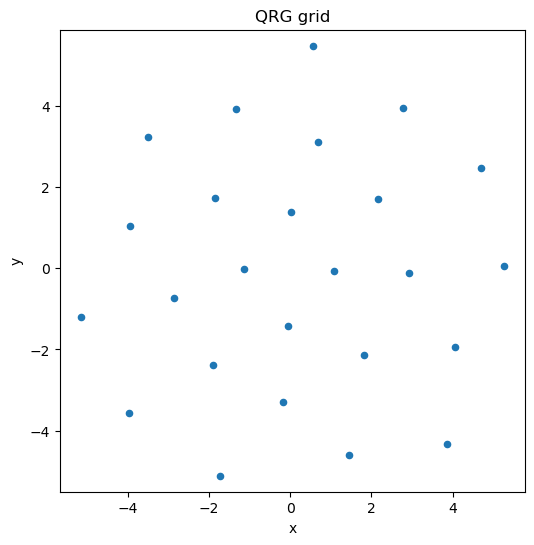

In [17]:
plot_grid_2d(rg_opt)

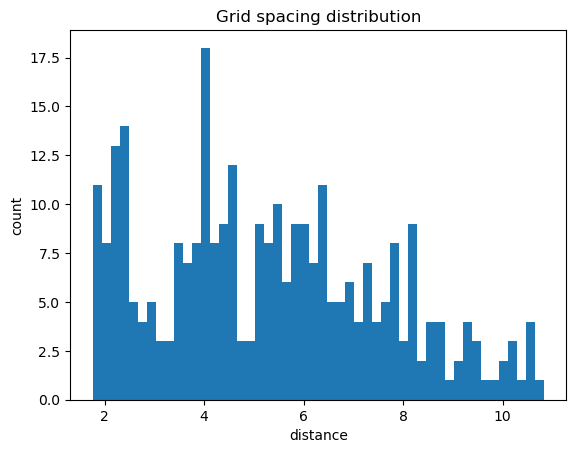

In [23]:
plot_distance_histogram(rg_opt)

## 2. 3D case

In [7]:
d1 = 3
NG = 125

rg = torch.randn(d1, NG)
V_ = torch.zeros(NG)
rrange1 = torch.ones(d1)

rg_opt, sigma, V = grids.construct_grid_qrg_fast(
    N_MC=500,
    rg=rg,
    V_=V_,
    P=P,
    rrange1=rrange1,
    device="cpu",
    step=0.1
)

Start optimizing QRG
Step 1250 | step_size = 0.1000 | energy = 28.3788
Step 2500 | step_size = 0.0900 | energy = 378.5503
Step 3750 | step_size = 0.0810 | energy = 0.0334
Step 5000 | step_size = 0.0729 | energy = 107.4235
Step 6250 | step_size = 0.0656 | energy = 22.2444
Step 7500 | step_size = 0.0590 | energy = 41.9829
Step 8750 | step_size = 0.0590 | energy = 45.8913
Step 10000 | step_size = 0.0531 | energy = 8.1081
Step 11250 | step_size = 0.0531 | energy = 0.1834
Step 12500 | step_size = 0.0531 | energy = 4.0200
Step 13750 | step_size = 0.0531 | energy = 1.8311
Step 15000 | step_size = 0.0531 | energy = 0.8764
Step 16250 | step_size = 0.0531 | energy = 1.7017
Step 17500 | step_size = 0.0478 | energy = 0.0086
Step 18750 | step_size = 0.0478 | energy = 0.5944
Step 20000 | step_size = 0.0478 | energy = 0.4892
Step 21250 | step_size = 0.0430 | energy = 0.0245
Step 22500 | step_size = 0.0430 | energy = 0.2431
Step 23750 | step_size = 0.0430 | energy = 0.3179
Step 25000 | step_size = 0.0

In [8]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

def plot_grid_3d(rg):
    """
    Plot 3D grid points.
    """

    coords = rg.T.cpu().numpy()

    fig = plt.figure(figsize=(7,6))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(coords[:,0], coords[:,1], coords[:,2], s=15)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title("QRG grid")

    plt.show()

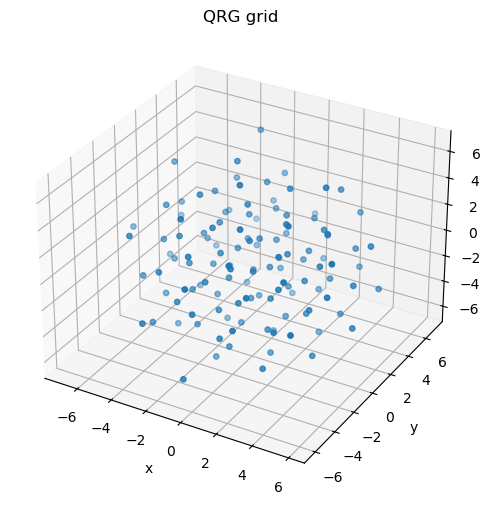

In [9]:
plot_grid_3d(rg_opt)

## 3. 4D and higher cases

In [27]:
d1 = 4
NG = 125

rg = torch.randn(d1, NG)
V_ = torch.zeros(NG)
rrange1 = torch.ones(d1)

rg_opt, sigma, V = grids.construct_grid_qrg_fast(
    N_MC=500,
    rg=rg,
    V_=V_,
    P=P,
    rrange1=rrange1,
    device="cpu",
    step=0.1
)

Start optimizing QRG
Step 1250 | step_size = 0.1000 | energy = 73.5252
Step 2500 | step_size = 0.1000 | energy = 0.1081
Step 3750 | step_size = 0.1000 | energy = 0.0496
Step 5000 | step_size = 0.1000 | energy = 0.0183
Step 6250 | step_size = 0.1000 | energy = 0.0365
Step 7500 | step_size = 0.1000 | energy = 0.0405
Step 8750 | step_size = 0.1000 | energy = 0.0934
Step 10000 | step_size = 0.0900 | energy = 0.0013
Step 11250 | step_size = 0.0900 | energy = 0.0014
Step 12500 | step_size = 0.0900 | energy = 0.0044
Step 13750 | step_size = 0.0900 | energy = 0.0024
Step 15000 | step_size = 0.0900 | energy = 0.0003
Step 16250 | step_size = 0.0900 | energy = 0.0005
Step 17500 | step_size = 0.0900 | energy = 0.0003
Step 18750 | step_size = 0.0810 | energy = 0.0000
Step 20000 | step_size = 0.0729 | energy = 0.0001
Step 21250 | step_size = 0.0656 | energy = 0.0000
Step 22500 | step_size = 0.0590 | energy = 0.0001
Step 23750 | step_size = 0.0590 | energy = 0.0000
Step 25000 | step_size = 0.0531 | e

In [35]:
from sklearn.decomposition import PCA

def plot_grid_pca(rg, n_components=2, i=0, j=1):

    coords = rg.T.cpu().numpy()

    pca = PCA(n_components)
    proj = pca.fit_transform(coords)

    plt.figure(figsize=(6,6))
    plt.scatter(proj[:,i], proj[:,j], s=20)

    plt.xlabel(F"PC{i}")
    plt.ylabel(F"PC{j}")
    plt.title("QRG grid (PCA projection)")
    plt.show()

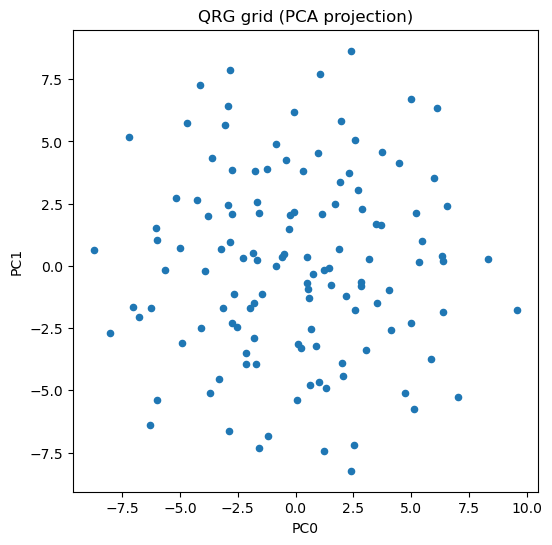

In [36]:
plot_grid_pca(rg_opt, 2, 0, 1)

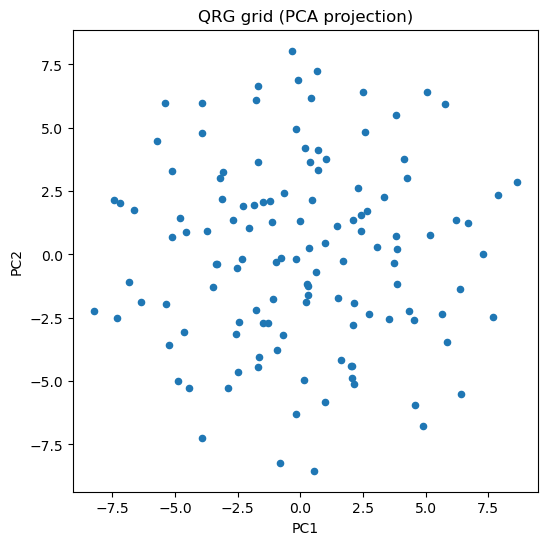

In [38]:
plot_grid_pca(rg_opt, 3, 1, 2)